In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# ==========================================
# 1. FEATURE SELECTION
# ==========================================
# Explicitly defining f0 to f25
BASE_FEATURES = [f'f{i}' for i in range(26)]
# Alphas added to base
STABLE_FEATURES = BASE_FEATURES + ['f0_speed', 'alpha_interaction', 'y_vol']
# Restricted set for the Jump-Hunter to prevent overfitting
CHAOS_FEATURES = ['f0_speed', 'alpha_interaction', 'y_vol', 'f0', 'f6', 'f12', 'f18']

# ==========================================
# 2. FEATURE ENGINEERING (PURGED & LEAK-PROOF)
# ==========================================
def engineer_features(df, vol_threshold=None):
    df = df.copy()
    
    # Sort to ensure time-series consistency for rolling windows
    df = df.sort_values(['date_id', 'time_id', 'symbol_id']).reset_index(drop=True)
    
    # Alphas (Chaos King Momentum)
    # Using groupby symbol_id to ensure deltas are calculated per-asset
    df['f0_delta'] = df.groupby('symbol_id')['f0'].diff().fillna(0)
    df['f0_speed'] = df.groupby('symbol_id')['f0_delta'].transform(lambda x: x.ewm(span=3).mean())
    df['alpha_interaction'] = df['f0_speed'] * (df['f0'] / (df['f6'] + 1e-8))
    
    # Volatility Regime Marker
    df['y_vol'] = df.groupby('symbol_id')['f0_delta'].transform(
        lambda x: x.rolling(100, min_periods=1).std()
    ).fillna(0.001)
    
    # Logic for Hard-Switch Threshold
    if vol_threshold is None:
        # Use only training data to find the 75th percentile of volatility
        vol_threshold = df['y_vol'].quantile(0.75)
        print(f"✅ Training Volatility Threshold Locked at: {vol_threshold:.6f}")
    
    df['is_chaos'] = (df['y_vol'] > vol_threshold).astype(int)
    
    # Fill any NaNs from rolling/diff with 0 to prevent validation errors
    df = df.fillna(0)
    return df, vol_threshold

# ==========================================
# 3. DATE-BASED PURGED SPLIT
# ==========================================
print("🛠️ Splitting and Engineering Features...")

# Splitting by Date ensures the model validates on a "Future" it has never seen
unique_dates = sorted(train_df['date_id'].unique())
split_date_idx = int(len(unique_dates) * 0.8)
split_date = unique_dates[split_date_idx]

train_raw = train_df[train_df['date_id'] < split_date].copy()
val_raw = train_df[train_df['date_id'] >= split_date].copy()

# Process both sets
train_proc, global_thresh = engineer_features(train_raw)
val_proc, _ = engineer_features(val_raw, vol_threshold=global_thresh)

# ==========================================
# 4. TRAINING THE SPECIALISTS
# ==========================================
# Specialist 1: THE STABILIZER (Standard GBDT)
print(f"📉 Training Specialist 1: The Stabilizer ({len(train_proc[train_proc['is_chaos']==0])} rows)")
model_stable = lgb.train(
    {'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'learning_rate': 0.05, 'num_leaves': 31},
    lgb.Dataset(train_proc[train_proc['is_chaos'] == 0][STABLE_FEATURES], 
                label=train_proc[train_proc['is_chaos'] == 0]['y'])
)

# Specialist 2: THE JUMP-HUNTER (DART - Extreme Regularization)
print(f"🔥 Training Specialist 2: The Jump-Hunter ({len(train_proc[train_proc['is_chaos']==1])} rows)")
chaos_params = {
    'boosting_type': 'dart',    # Prevents overfitting to Fold 4 madness
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.03,
    'num_leaves': 15,           # Shallow trees to focus on Alphas
    'drop_rate': 0.15,
    'feature_fraction': 0.7,
    'verbosity': -1
}
model_chaos = lgb.train(
    chaos_params, 
    lgb.Dataset(train_proc[train_proc['is_chaos'] == 1][CHAOS_FEATURES], 
                label=train_proc[train_proc['is_chaos'] == 1]['y']),
    num_boost_round=150
)

# ==========================================
# 5. HONEST VALIDATION REPORT
# ==========================================
val_proc['preds'] = 0.0
s_mask = (val_proc['is_chaos'] == 0)
c_mask = (val_proc['is_chaos'] == 1)

if s_mask.any():
    val_proc.loc[s_mask, 'preds'] = model_stable.predict(val_proc.loc[s_mask, STABLE_FEATURES])
if c_mask.any():
    val_proc.loc[c_mask, 'preds'] = model_chaos.predict(val_proc.loc[c_mask, CHAOS_FEATURES])

val_rmse = np.sqrt(mean_squared_error(val_proc['y'], val_proc['preds']))
print("\n" + "="*40)
print(f"📊 HONEST PURGED VALIDATION REPORT")
print(f"🌎 GLOBAL RMSE: {val_rmse:.6f}")
print("="*40)

# ==========================================
# 6. TEST INFERENCE & CSV SUBMISSION
# ==========================================
print("🔮 Applying Logic to Test Set...")
test_proc, _ = engineer_features(test_df, vol_threshold=global_thresh)

# Initializing y for prediction
test_proc['y'] = 0.0

t_s_mask = (test_proc['is_chaos'] == 0)
t_c_mask = (test_proc['is_chaos'] == 1)

if t_s_mask.any():
    test_proc.loc[t_s_mask, 'y'] = model_stable.predict(test_proc.loc[t_s_mask, STABLE_FEATURES])
if t_c_mask.any():
    test_proc.loc[t_c_mask, 'y'] = model_chaos.predict(test_proc.loc[t_c_mask, CHAOS_FEATURES])

# FINAL SUBMISSION FORMAT: Id (identifier), y (prediction)
submission = test_proc[['Id', 'y']].copy()
submission.to_csv('submission.csv', index=False)

print(f"🏆 Final submission.csv generated with {len(submission)} rows.")
print(submission.head())

🛠️ Splitting and Engineering Features...
✅ Training Volatility Threshold Locked at: 0.002141
📉 Training Specialist 1: The Stabilizer (1204634 rows)
🔥 Training Specialist 2: The Jump-Hunter (401545 rows)

📊 HONEST PURGED VALIDATION REPORT
🌎 GLOBAL RMSE: 0.002251
🔮 Applying Logic to Test Set...
🏆 Final submission.csv generated with 2510026 rows.
        Id         y
0  2017129  0.000802
1  2017133  0.000256
2  2017136  0.000003
3  2017140  0.000491
4  2017141  0.000195


In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import time

# ==========================================
# 1. FEATURE DEFINITIONS
# ==========================================
BASE_FEATURES = [f'f{i}' for i in range(26)]
STABLE_FEATURES = BASE_FEATURES + ['f0_speed', 'alpha_interaction', 'y_vol']
CHAOS_FEATURES = ['f0_speed', 'alpha_interaction', 'y_vol', 'f0', 'f6', 'f12', 'f18']

# ==========================================
# 2. FEATURE ENGINE
# ==========================================
def engineer_features(df, vol_threshold=None):
    df = df.copy()
    df = df.sort_values(['date_id', 'time_id', 'symbol_id']).reset_index(drop=True)
    
    # Alphas
    df['f0_delta'] = df.groupby('symbol_id')['f0'].diff().fillna(0)
    df['f0_speed'] = df.groupby('symbol_id')['f0_delta'].transform(lambda x: x.ewm(span=3).mean())
    df['alpha_interaction'] = df['f0_speed'] * (df['f0'] / (df['f6'] + 1e-8))
    
    # Volatility
    df['y_vol'] = df.groupby('symbol_id')['f0_delta'].transform(
        lambda x: x.rolling(100, min_periods=1).std()
    ).fillna(0.001)
    
    if vol_threshold is None:
        vol_threshold = df['y_vol'].quantile(0.75)
    
    df['is_chaos'] = (df['y_vol'] > vol_threshold).astype(int)
    return df.fillna(0), vol_threshold

# ==========================================
# 3. THE RUN
# ==========================================
print("🔥 Running Ooga Booga Strategy...")

# 1. Purged Split
unique_dates = sorted(train_df['date_id'].unique())
split_date = unique_dates[int(len(unique_dates) * 0.8)]
train_proc, thresh = engineer_features(train_df[train_df['date_id'] < split_date])
val_proc, _ = engineer_features(train_df[train_df['date_id'] >= split_date], vol_threshold=thresh)

# 2. Train Specialists
model_stable = lgb.train(
    {'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'learning_rate': 0.05, 'num_leaves': 31},
    lgb.Dataset(train_proc[train_proc['is_chaos']==0][STABLE_FEATURES], label=train_proc[train_proc['is_chaos']==0]['y'])
)

model_chaos = lgb.train(
    {'boosting_type': 'dart', 'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.03, 
     'num_leaves': 15, 'drop_rate': 0.15, 'feature_fraction': 0.7, 'verbosity': -1},
    lgb.Dataset(train_proc[train_proc['is_chaos']==1][CHAOS_FEATURES], label=train_proc[train_proc['is_chaos']==1]['y']),
    num_boost_round=150
)

# 3. Test Inference
test_proc, _ = engineer_features(test_df, vol_threshold=thresh)
test_proc['y'] = 0.0

# Apply Logic
test_proc.loc[test_proc['is_chaos']==0, 'y'] = model_stable.predict(test_proc.loc[test_proc['is_chaos']==0, STABLE_FEATURES])
test_proc.loc[test_proc['is_chaos']==1, 'y'] = model_chaos.predict(test_proc.loc[test_proc['is_chaos']==1, CHAOS_FEATURES])

# ==========================================
# 4. THE FRESH FILE SAVE
# ==========================================
filename = f"ooga_booga_final_{int(time.time())}.csv"
submission = test_proc[['Id', 'y']].copy()
submission.to_csv(filename, index=False)

# ALSO save as submission.csv so the competition system can find it
submission.to_csv('submission.csv', index=False)

print("\n" + "="*40)
print(f"✅ FRESH FILE SAVED AS: {filename}")
print(f"✅ ALSO OVERWROTE: submission.csv")
print(f"📊 Prediction Mean: {submission['y'].mean():.8f}")
print(f"📊 Prediction Std:  {submission['y'].std():.8f}")
print("="*40)

🔥 Running Ooga Booga Strategy...

✅ FRESH FILE SAVED AS: ooga_booga_final_1769246591.csv
✅ ALSO OVERWROTE: submission.csv
📊 Prediction Mean: 0.00006352
📊 Prediction Std:  0.00202241


In [5]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import time

# ==========================================
# 1. FEATURE & REGIME SETTINGS
# ==========================================
BASE_FEATURES = [f'f{i}' for i in range(26)]
STABLE_FEATURES = BASE_FEATURES + ['f0_speed', 'alpha_interaction', 'y_vol']
CHAOS_FEATURES = ['f0_speed', 'alpha_interaction', 'y_vol', 'f0', 'f6', 'f12', 'f18']

def engineer_features(df, vol_threshold=None):
    df = df.copy()
    df = df.sort_values(['date_id', 'time_id', 'symbol_id']).reset_index(drop=True)
    df['f0_delta'] = df.groupby('symbol_id')['f0'].diff().fillna(0)
    df['f0_speed'] = df.groupby('symbol_id')['f0_delta'].transform(lambda x: x.ewm(span=3).mean())
    df['alpha_interaction'] = df['f0_speed'] * (df['f0'] / (df['f6'] + 1e-8))
    df['y_vol'] = df.groupby('symbol_id')['f0_delta'].transform(lambda x: x.rolling(100, min_periods=1).std()).fillna(0.001)
    
    if vol_threshold is None:
        vol_threshold = df['y_vol'].quantile(0.75)
    
    df['is_chaos'] = (df['y_vol'] > vol_threshold).astype(int)
    return df.fillna(0), vol_threshold

# ==========================================
# 2. THE PURGED VALIDATION WORKFLOW
# ==========================================
print("📈 Splitting dates for Purged Validation...")
unique_dates = sorted(train_df['date_id'].unique())
split_date = unique_dates[int(len(unique_dates) * 0.8)]

train_proc, thresh = engineer_features(train_df[train_df['date_id'] < split_date])
val_proc, _ = engineer_features(train_df[train_df['date_id'] >= split_date], vol_threshold=thresh)

# --- Training ---
print(f"📉 Training Stabilizer (Standard GBDT)...")
model_stable = lgb.train(
    {'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'learning_rate': 0.05, 'num_leaves': 31},
    lgb.Dataset(train_proc[train_proc['is_chaos']==0][STABLE_FEATURES], label=train_proc[train_proc['is_chaos']==0]['y'])
)

print(f"🔥 Training Jump-Hunter (DART)...")
model_chaos = lgb.train(
    {'boosting_type': 'dart', 'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.03, 
     'num_leaves': 15, 'drop_rate': 0.15, 'feature_fraction': 0.7, 'verbosity': -1},
    lgb.Dataset(train_proc[train_proc['is_chaos']==1][CHAOS_FEATURES], label=train_proc[train_proc['is_chaos']==1]['y']),
    num_boost_round=150
)

# --- Validation Diagnostics ---
val_proc['preds'] = 0.0
val_proc.loc[val_proc['is_chaos']==0, 'preds'] = model_stable.predict(val_proc.loc[val_proc['is_chaos']==0, STABLE_FEATURES])
val_proc.loc[val_proc['is_chaos']==1, 'preds'] = model_chaos.predict(val_proc.loc[val_proc['is_chaos']==1, CHAOS_FEATURES])

rmse_stable = np.sqrt(mean_squared_error(val_proc[val_proc['is_chaos']==0]['y'], val_proc[val_proc['is_chaos']==0]['preds']))
rmse_chaos = np.sqrt(mean_squared_error(val_proc[val_proc['is_chaos']==1]['y'], val_proc[val_proc['is_chaos']==1]['preds']))
rmse_global = np.sqrt(mean_squared_error(val_proc['y'], val_proc['preds']))

# ==========================================
# 3. TEST INFERENCE & FILE GENERATION
# ==========================================
test_proc, _ = engineer_features(test_df, vol_threshold=thresh)
test_proc['y'] = 0.0
test_proc.loc[test_proc['is_chaos']==0, 'y'] = model_stable.predict(test_proc.loc[test_proc['is_chaos']==0, STABLE_FEATURES])
test_proc.loc[test_proc['is_chaos']==1, 'y'] = model_chaos.predict(test_proc.loc[test_proc['is_chaos']==1, CHAOS_FEATURES])

# Generate Fresh File
ts = int(time.time())
submission = test_proc[['Id', 'y']].copy()
submission.to_csv(f'ooga_booga_{ts}.csv', index=False)
submission.to_csv('submission.csv', index=False)

print("\n" + "="*45)
print(f"📊 DIAGNOSTIC PURGED REPORT")
print(f"✅ STABLE REGIME RMSE: {rmse_stable:.6f}")
print(f"🔥 CHAOS  REGIME RMSE: {rmse_chaos:.6f}")
print(f"🌎 GLOBAL TOTAL  RMSE: {rmse_global:.6f}")
print("-" * 45)
print(f"📂 SAVED AS: ooga_booga_{ts}.csv")
print(f"📊 Pred Mean: {submission['y'].mean():.8f} | Std: {submission['y'].std():.8f}")
print("="*45)

📈 Splitting dates for Purged Validation...
📉 Training Stabilizer (Standard GBDT)...
🔥 Training Jump-Hunter (DART)...

📊 DIAGNOSTIC PURGED REPORT
✅ STABLE REGIME RMSE: 0.001775
🔥 CHAOS  REGIME RMSE: 0.003605
🌎 GLOBAL TOTAL  RMSE: 0.002251
---------------------------------------------
📂 SAVED AS: ooga_booga_1769246694.csv
📊 Pred Mean: 0.00006352 | Std: 0.00202241


In [6]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import time

# ==========================================
# 1. UPDATED FEATURE SETS
# ==========================================
BASE_FEATURES = [f'f{i}' for i in range(26)]
# Added 'symbol_mean' to give the model "Asset Personality"
STABLE_FEATURES = BASE_FEATURES + ['f0_speed', 'alpha_interaction', 'y_vol', 'symbol_mean']
CHAOS_FEATURES = ['f0_speed', 'alpha_interaction', 'y_vol', 'f0', 'f6', 'f12', 'symbol_mean']

def engineer_features(df, vol_threshold=None, symbol_map=None):
    df = df.copy()
    df = df.sort_values(['date_id', 'time_id', 'symbol_id']).reset_index(drop=True)
    
    # Alphas
    df['f0_delta'] = df.groupby('symbol_id')['f0'].diff().fillna(0)
    df['f0_speed'] = df.groupby('symbol_id')['f0_delta'].transform(lambda x: x.ewm(span=3).mean())
    df['alpha_interaction'] = df['f0_speed'] * (df['f0'] / (df['f6'] + 1e-8))
    df['y_vol'] = df.groupby('symbol_id')['f0_delta'].transform(lambda x: x.rolling(100, min_periods=1).std()).fillna(0.001)
    
    # 2. Asset Personality (Target Encoding)
    if symbol_map is None:
        # We use the mean of 'y' per symbol from the training set
        symbol_map = df.groupby('symbol_id')['y'].mean().to_dict()
    
    df['symbol_mean'] = df['symbol_id'].map(symbol_map).fillna(0)
    
    if vol_threshold is None:
        vol_threshold = df['y_vol'].quantile(0.75)
    
    df['is_chaos'] = (df['y_vol'] > vol_threshold).astype(int)
    return df.fillna(0), vol_threshold, symbol_map

# ==========================================
# 2. THE PURGED WORKFLOW
# ==========================================
unique_dates = sorted(train_df['date_id'].unique())
split_date = unique_dates[int(len(unique_dates) * 0.8)]

train_proc, thresh, s_map = engineer_features(train_df[train_df['date_id'] < split_date])
val_proc, _, _ = engineer_features(train_df[train_df['date_id'] >= split_date], vol_threshold=thresh, symbol_map=s_map)

# Specialist 1: THE STABILIZER (Huber GBDT)
# Huber is more robust to the small noise in the stable regime
print(f"📉 Training Huber Stabilizer...")
model_stable = lgb.train(
    {'objective': 'huber', 'metric': 'rmse', 'verbosity': -1, 'learning_rate': 0.05, 'num_leaves': 31},
    lgb.Dataset(train_proc[train_proc['is_chaos']==0][STABLE_FEATURES], label=train_proc[train_proc['is_chaos']==0]['y'])
)

# Specialist 2: THE JUMP-HUNTER (Huber DART)
# Huber prevents the DART trees from over-reacting to Fold 4 spikes
print(f"🔥 Training Huber Jump-Hunter...")
model_chaos = lgb.train(
    {'boosting_type': 'dart', 'objective': 'huber', 'metric': 'rmse', 'learning_rate': 0.03, 
     'num_leaves': 15, 'drop_rate': 0.15, 'feature_fraction': 0.7, 'verbosity': -1},
    lgb.Dataset(train_proc[train_proc['is_chaos']==1][CHAOS_FEATURES], label=train_proc[train_proc['is_chaos']==1]['y']),
    num_boost_round=150
)

# ==========================================
# 3. TEST INFERENCE
# ==========================================
test_proc, _, _ = engineer_features(test_df, vol_threshold=thresh, symbol_map=s_map)
test_proc['y'] = 0.0
test_proc.loc[test_proc['is_chaos']==0, 'y'] = model_stable.predict(test_proc.loc[test_proc['is_chaos']==0, STABLE_FEATURES])
test_proc.loc[test_proc['is_chaos']==1, 'y'] = model_chaos.predict(test_proc.loc[test_proc['is_chaos']==1, CHAOS_FEATURES])

# ==========================================
# 4. FINAL HUBER REPORT
# ==========================================
val_proc['preds'] = 0.0
val_proc.loc[val_proc['is_chaos']==0, 'preds'] = model_stable.predict(val_proc.loc[val_proc['is_chaos']==0, STABLE_FEATURES])
val_proc.loc[val_proc['is_chaos']==1, 'preds'] = model_chaos.predict(val_proc.loc[val_proc['is_chaos']==1, CHAOS_FEATURES])
rmse_global = np.sqrt(mean_squared_error(val_proc['y'], val_proc['preds']))

ts = int(time.time())
submission = test_proc[['Id', 'y']].copy()
submission.to_csv('submission.csv', index=False)

print("\n" + "="*45)
print(f"📊 HUBER-REGIME VALIDATION: {rmse_global:.6f}")
print(f"📊 Pred Mean: {submission['y'].mean():.8f}")
print(f"📂 Saved as: submission.csv")
print("="*45)

📉 Training Huber Stabilizer...
🔥 Training Huber Jump-Hunter...

📊 HUBER-REGIME VALIDATION: 0.002250
📊 Pred Mean: 0.00000807
📂 Saved as: submission.csv


In [7]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# ==========================================
# 1. SHARPE-RATIO ENGINEERING
# ==========================================
def engineer_features_offensive(df, vol_threshold=None):
    df = df.copy()
    df = df.sort_values(['date_id', 'time_id', 'symbol_id']).reset_index(drop=True)
    
    # Core Alphas
    df['f0_delta'] = df.groupby('symbol_id')['f0'].diff().fillna(0)
    df['f0_speed'] = df.groupby('symbol_id')['f0_delta'].transform(lambda x: x.ewm(span=3).mean())
    
    # Local Volatility (The denominator)
    df['local_vol'] = df.groupby('symbol_id')['f0_delta'].transform(
        lambda x: x.rolling(50, min_periods=1).std()
    ).replace(0, 0.001).fillna(0.001)
    
    # THE OFFENSIVE TARGET: Predict y scaled by its own volatility
    # This makes the target "unitless" and easier for LightGBM to hit
    if 'y' in df.columns:
        df['target_scaled'] = df['y'] / df['local_vol']
    
    if vol_threshold is None:
        vol_threshold = df['local_vol'].quantile(0.80) # Tighten the Chaos gate
        
    df['is_chaos'] = (df['local_vol'] > vol_threshold).astype(int)
    return df.fillna(0), vol_threshold

# ==========================================
# 2. TRAINING ON THE "SCALED" SIGNAL
# ==========================================
print("⚡ Engineering Offensive Features...")
train_proc, thresh = engineer_features_offensive(train_df)

# Features that focus on pure signal
FEATURES = [f'f{i}' for i in range(26)] + ['f0_speed', 'local_vol']

# We train a single, high-capacity model on the Scaled Target
# This is often better than two models when the target is normalized
print("🏹 Training the Sharpe-Focus Model...")
model = lgb.train(
    {
        'objective': 'regression',
        'metric': 'rmse',
        'learning_rate': 0.05,
        'num_leaves': 63,      # More leaves to capture the complex signal
        'feature_fraction': 0.7,
        'lambda_l1': 0.1,      # Sparsity penalty
        'verbosity': -1
    },
    lgb.Dataset(train_proc[FEATURES], label=train_proc['target_scaled']),
    num_boost_round=250
)

# ==========================================
# 3. INFERENCE (The "Multiply-Back" Step)
# ==========================================
print("🔮 Applying Offensive Inference...")
test_proc, _ = engineer_features_offensive(test_df, vol_threshold=thresh)

# 1. Predict the "Scaled" value
scaled_preds = model.predict(test_proc[FEATURES])

# 2. Rescale it back to the real price world
# Pred = (y / vol) * vol
test_proc['y'] = scaled_preds * test_proc['local_vol']

# Guardrail: Clip extreme outliers that cause 0.009 failures
limit = test_proc['y'].quantile(0.999)
test_proc['y'] = test_proc['y'].clip(-limit, limit)

# ==========================================
# 4. SUBMISSION
# ==========================================
submission = test_proc[['Id', 'y']].copy()
submission.to_csv('submission.csv', index=False)

print("\n" + "="*45)
print(f"🚀 SHARPE-FOCUS SUBMISSION READY")
print(f"📊 Pred Mean: {submission['y'].mean():.8f}")
print(f"📊 Pred Max:  {submission['y'].max():.8f}")
print(f"🛡️ Outlier Clipping Limit: {limit:.6f}")
print("="*45)

⚡ Engineering Offensive Features...
🏹 Training the Sharpe-Focus Model...
🔮 Applying Offensive Inference...

🚀 SHARPE-FOCUS SUBMISSION READY
📊 Pred Mean: 0.00133908
📊 Pred Max:  0.22253429
🛡️ Outlier Clipping Limit: 0.222534


In [8]:
from sklearn.metrics import mean_squared_error

# 1. Prepare Purged Split
unique_dates = sorted(train_df['date_id'].unique())
split_date = unique_dates[int(len(unique_dates) * 0.8)]

train_raw = train_df[train_df['date_id'] < split_date].copy()
val_raw = train_df[train_df['date_id'] >= split_date].copy()

# 2. Engineer Features (including the scaled target)
train_proc, thresh = engineer_features_offensive(train_raw)
val_proc, _ = engineer_features_offensive(val_raw, vol_threshold=thresh)

# 3. Train on Scaled Target
FEATURES = [f'f{i}' for i in range(26)] + ['f0_speed', 'local_vol']
model = lgb.train(
    {'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.05, 'num_leaves': 63, 'verbosity': -1},
    lgb.Dataset(train_proc[FEATURES], label=train_proc['target_scaled'])
)

# 4. Validate (The Crucial Rescaling Step)
val_proc['scaled_preds'] = model.predict(val_proc[FEATURES])

# RESCALE: Pred_Price = Pred_Scaled * Local_Volatility
val_proc['final_preds'] = val_proc['scaled_preds'] * val_proc['local_vol']

# 5. Calculate Real-World RMSE
rmse_unscaled = np.sqrt(mean_squared_error(val_proc['y'], val_proc['final_preds']))

print("\n" + "="*45)
print(f"📊 SHARPE-FOCUS REAL-WORLD RMSE: {rmse_unscaled:.6f}")
print(f"💡 (This is the error in the same units as the LB)")
print("="*45)


📊 SHARPE-FOCUS REAL-WORLD RMSE: 0.002258
💡 (This is the error in the same units as the LB)


In [9]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import time

# ==========================================
# 1. FEATURES & SCALING
# ==========================================
FEATURES = [f'f{i}' for i in range(26)] + ['f0_speed', 'local_vol']

def engineer_offensive_v2(df, vol_threshold=None):
    df = df.copy()
    df = df.sort_values(['date_id', 'time_id', 'symbol_id']).reset_index(drop=True)
    
    df['f0_delta'] = df.groupby('symbol_id')['f0'].diff().fillna(0)
    df['f0_speed'] = df.groupby('symbol_id')['f0_delta'].transform(lambda x: x.ewm(span=3).mean())
    df['local_vol'] = df.groupby('symbol_id')['f0_delta'].transform(
        lambda x: x.rolling(50, min_periods=1).std()
    ).replace(0, 0.001).fillna(0.001)
    
    # Target Scaling: Sharpe-style
    if 'y' in df.columns:
        df['target_scaled'] = df['y'] / df['local_vol']
    
    return df.fillna(0)

# ==========================================
# 2. THE "SIGMOIDAL" INFERENCE (The Top-50 Secret)
# ==========================================
print("⚡ Training Final Offensive Model...")
# Use the whole train set for the final attempt to maximize knowledge
train_proc = engineer_offensive_v2(train_df)

model = lgb.train(
    {
        'objective': 'regression',
        'metric': 'rmse',
        'learning_rate': 0.03,
        'num_leaves': 48,
        'feature_fraction': 0.7,
        'lambda_l2': 0.5,
        'verbosity': -1
    },
    lgb.Dataset(train_proc[FEATURES], label=train_proc['target_scaled']),
    num_boost_round=300
)

# ==========================================
# 3. TEST INFERENCE WITH THE "SAFETY VALVE"
# ==========================================
print("🔮 Applying Tanh-Scaled Inference...")
test_proc = engineer_offensive_v2(test_df)

# Step A: Raw Scaled Prediction
raw_scaled_preds = model.predict(test_proc[FEATURES])

# Step B: Apply Tanh to "Squash" the outliers before re-scaling
# This ensures that even if the model goes crazy, the prediction stays sane.
squashed_preds = np.tanh(raw_scaled_preds) * 2.0  # Max scaled prediction is now +/- 2.0

# Step C: Rescale back to price space
test_proc['y'] = squashed_preds * test_proc['local_vol']

# ==========================================
# 4. FINAL SUBMISSION
# ==========================================
submission = test_proc[['Id', 'y']].copy()
submission.to_csv('submission.csv', index=False)

print("\n" + "="*45)
print(f"🚀 TANH-OFFENSIVE SUBMISSION READY")
print(f"📊 New Pred Mean: {submission['y'].mean():.8f}")
print(f"📊 New Pred Max:  {submission['y'].max():.8f}") 
print(f"💡 (Max should be significantly lower than 0.22)")
print("="*45)

⚡ Training Final Offensive Model...
🔮 Applying Tanh-Scaled Inference...

🚀 TANH-OFFENSIVE SUBMISSION READY
📊 New Pred Mean: 0.00041476
📊 New Pred Max:  0.32993635
💡 (Max should be significantly lower than 0.22)


In [10]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# ==========================================
# 1. VOLATILITY CLAMPING ENGINE
# ==========================================
def engineer_clamped_features(df, vol_cap=None):
    df = df.copy()
    df = df.sort_values(['date_id', 'time_id', 'symbol_id']).reset_index(drop=True)
    
    df['f0_delta'] = df.groupby('symbol_id')['f0'].diff().fillna(0)
    df['local_vol'] = df.groupby('symbol_id')['f0_delta'].transform(
        lambda x: x.rolling(50, min_periods=1).std()
    ).replace(0, 0.001).fillna(0.001)
    
    # --- THE FIX ---
    if vol_cap is None:
        vol_cap = df['local_vol'].quantile(0.99)
        print(f"🛡️ Volatility Cap Set at: {vol_cap:.6f}")
    
    df['local_vol'] = df['local_vol'].clip(0, vol_cap)
    # ---------------
    
    if 'y' in df.columns:
        df['target_scaled'] = df['y'] / df['local_vol']
    
    return df.fillna(0), vol_cap

# ==========================================
# 2. THE ULTIMATE TRAINING
# ==========================================
FEATURES = [f'f{i}' for i in range(26)] + ['f0_delta', 'local_vol']
train_proc, global_vol_cap = engineer_clamped_features(train_df)

model = lgb.train(
    {'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.03, 'num_leaves': 31, 'verbosity': -1},
    lgb.Dataset(train_proc[FEATURES], label=train_proc['target_scaled']),
    num_boost_round=200
)

# ==========================================
# 3. THE "SANE" INFERENCE
# ==========================================
test_proc, _ = engineer_clamped_features(test_df, vol_cap=global_vol_cap)

# A. Raw Scaled Prediction
raw_scaled = model.predict(test_proc[FEATURES])

# B. The Double-Guardrail (Tanh + Rescale)
# We use a tighter Tanh (1.0) to ensure we stay within 1 Standard Deviation
test_proc['y'] = np.tanh(raw_scaled) * test_proc['local_vol']

# ==========================================
# 4. FINAL SUBMISSION
# ==========================================
submission = test_proc[['Id', 'y']].copy()
submission.to_csv('submission.csv', index=False)

print("\n" + "="*45)
print(f"🏆 CLAMPED-VOL SUBMISSION READY")
print(f"📊 Pred Mean: {submission['y'].mean():.8f}")
print(f"📊 Pred Max:  {submission['y'].max():.8f} (TARGET: < 0.01)")
print("="*45)

🛡️ Volatility Cap Set at: 0.008173

🏆 CLAMPED-VOL SUBMISSION READY
📊 Pred Mean: 0.00001675
📊 Pred Max:  0.00134435 (TARGET: < 0.01)


In [11]:
from sklearn.metrics import mean_squared_error

# 1. Prepare Purged Split (80/20)
unique_dates = sorted(train_df['date_id'].unique())
split_date = unique_dates[int(len(unique_dates) * 0.8)]
train_raw, val_raw = train_df[train_df['date_id'] < split_date].copy(), train_df[train_df['date_id'] >= split_date].copy()

# 2. Engineer with Clamping
train_proc, global_vol_cap = engineer_clamped_features(train_raw)
val_proc, _ = engineer_clamped_features(val_raw, vol_cap=global_vol_cap)

# 3. Train on Scaled Target
FEATURES = [f'f{i}' for i in range(26)] + ['f0_delta', 'local_vol']
model = lgb.train(
    {'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.03, 'num_leaves': 31, 'verbosity': -1},
    lgb.Dataset(train_proc[FEATURES], label=train_proc['target_scaled']),
    num_boost_round=200
)

# 4. Validate with Tanh Anchor
val_proc['scaled_preds'] = model.predict(val_proc[FEATURES])
val_proc['final_preds'] = np.tanh(val_proc['scaled_preds']) * val_proc['local_vol']

# 5. Final RMSE check
rmse_unscaled = np.sqrt(mean_squared_error(val_proc['y'], val_proc['final_preds']))

print("\n" + "="*45)
print(f"📊 CLAMPED SHARPE RMSE: {rmse_unscaled:.6f}")
print(f"📈 Prediction Max (Sane Check): {val_proc['final_preds'].max():.6f}")
print("="*45)

🛡️ Volatility Cap Set at: 0.008584

📊 CLAMPED SHARPE RMSE: 0.002249
📈 Prediction Max (Sane Check): 0.002979


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Hit Rate (Directional Accuracy)
val_proc['correct_direction'] = ((val_proc['y'] > 0) == (val_proc['final_preds'] > 0)).astype(int)
hit_rate_stable = val_proc[val_proc['local_vol'] <= global_vol_cap]['correct_direction'].mean()
hit_rate_chaos = val_proc[val_proc['local_vol'] > global_vol_cap]['correct_direction'].mean()

# 2. Check for "Outlier Bleed"
# We want to see if the errors are 'Normal' or 'Fat-Tailed'
val_proc['error'] = val_proc['y'] - val_proc['final_preds']

print("\n" + "="*45)
print(f"✅ STABLE HIT RATE: {hit_rate_stable:.2%}")
print(f"🔥 CHAOS HIT RATE:  {hit_rate_chaos:.2%}")
print("-" * 45)

# 3. Alpha Correlation Check
correlation = val_proc[['final_preds', 'f0_speed']].corr().iloc[0,1]
print(f"🧪 ALPHA CORRELATION (f0_speed): {correlation:.4f}")

# 4. Visual Verification
plt.figure(figsize=(12, 5))

# Plot Error Distribution
plt.subplot(1, 2, 1)
sns.histplot(val_proc['error'], bins=100, kde=True, color='purple')
plt.title('Error Distribution (Should be Bell-Shaped)')

# Plot Predicted vs Actual for a sample
plt.subplot(1, 2, 2)
plt.scatter(val_proc['y'].iloc[:5000], val_proc['final_preds'].iloc[:5000], alpha=0.1)
plt.axline((0, 0), slope=1, color='red', linestyle='--')
plt.xlabel('Actual Y')
plt.ylabel('Predicted Y')
plt.title('Prediction Alignment')

plt.tight_layout()
plt.show()

print("="*45)


✅ STABLE HIT RATE: 34.73%
🔥 CHAOS HIT RATE:  nan%
---------------------------------------------


KeyError: "['f0_speed'] not in index"

In [13]:
import pandas as pd
import numpy as np
import lightgbm as lgb

# 1. Cleaner Feature Engineering (Ensures f0_speed is kept)
def engineer_final_sanity(df, vol_cap=None):
    df = df.copy()
    # Ensure correct order
    df = df.sort_values(['date_id', 'time_id', 'symbol_id'])
    
    # Core Signal
    df['f0_delta'] = df.groupby('symbol_id')['f0'].diff().fillna(0)
    df['f0_speed'] = df.groupby('symbol_id')['f0_delta'].transform(lambda x: x.ewm(span=3).mean())
    
    # Volatility
    df['local_vol'] = df.groupby('symbol_id')['f0_delta'].transform(
        lambda x: x.rolling(50, min_periods=1).std()
    ).replace(0, 0.001).fillna(0.001)
    
    if vol_cap is None:
        vol_cap = df['local_vol'].quantile(0.99)
    df['local_vol'] = df['local_vol'].clip(0, vol_cap)
    
    # The Inversion Fix: Include raw f0 to detect mean reversion levels
    if 'y' in df.columns:
        df['target_scaled'] = df['y'] / df['local_vol']
    
    return df.fillna(0), vol_cap

# 2. Re-Train with "Anti-Inversion" Focus
print("🛡️ Re-Engineering with Mean Reversion Guard...")
train_proc, global_cap = engineer_final_sanity(train_df)
FEATURES = [f'f{i}' for i in range(26)] + ['f0_speed', 'local_vol']

# Using a slightly deeper model to catch the "Inversion" logic
model = lgb.train(
    {'objective': 'regression', 'learning_rate': 0.05, 'num_leaves': 63, 'verbosity': -1},
    lgb.Dataset(train_proc[FEATURES], label=train_proc['target_scaled']),
    num_boost_round=150
)

# 3. Final Check on Validation
unique_dates = sorted(train_df['date_id'].unique())
split_date = unique_dates[int(len(unique_dates) * 0.8)]
val_raw = train_df[train_df['date_id'] >= split_date]
val_proc, _ = engineer_final_sanity(val_raw, vol_cap=global_cap)

val_proc['final_preds'] = np.tanh(model.predict(val_proc[FEATURES])) * val_proc['local_vol']
hit_rate = ((val_proc['y'] > 0) == (val_proc['final_preds'] > 0)).mean()

print(f"\n✅ NEW VALIDATION HIT RATE: {hit_rate:.2%}")

# 4. Final Submission Generate
test_proc, _ = engineer_final_sanity(test_df, vol_cap=global_cap)
test_proc['y'] = np.tanh(model.predict(test_proc[FEATURES])) * test_proc['local_vol']
test_proc[['Id', 'y']].to_csv('submission.csv', index=False)

🛡️ Re-Engineering with Mean Reversion Guard...

✅ NEW VALIDATION HIT RATE: 35.20%


In [14]:
import pandas as pd
import numpy as np
import lightgbm as lgb

# 1. Use the EXACT same engineering from the 35% run
def engineer_inverted(df, vol_cap=None):
    df = df.copy().sort_values(['date_id', 'time_id', 'symbol_id'])
    df['f0_delta'] = df.groupby('symbol_id')['f0'].diff().fillna(0)
    df['local_vol'] = df.groupby('symbol_id')['f0_delta'].transform(
        lambda x: x.rolling(50, min_periods=1).std()
    ).replace(0, 0.001).fillna(0.001)
    
    if vol_cap is None:
        vol_cap = df['local_vol'].quantile(0.99)
    df['local_vol'] = df['local_vol'].clip(0, vol_cap)
    
    if 'y' in df.columns:
        df['target_scaled'] = df['y'] / df['local_vol']
    
    return df.fillna(0), vol_cap

# 2. Train the "Mirror" Model
train_proc, global_cap = engineer_inverted(train_df)
FEATURES = [f'f{i}' for i in range(26)] + ['local_vol'] # Dropping f0_speed to let the model find its own momentum

model = lgb.train(
    {'objective': 'regression', 'learning_rate': 0.05, 'num_leaves': 63, 'verbosity': -1},
    lgb.Dataset(train_proc[FEATURES], label=train_proc['target_scaled']),
    num_boost_round=150
)

# 3. THE INVERSION INFERENCE
print("🔄 Flipping the Signal Engine...")
test_proc, _ = engineer_inverted(test_df, vol_cap=global_cap)

# A. Get raw prediction
raw_preds = model.predict(test_proc[FEATURES])

# B. THE FLIP: Multiply by -1 
# Since hit rate was 35%, -1 * raw_preds should result in a 65% hit rate
final_preds_scaled = raw_preds * -1.0

# C. Apply Sane-Clamping
test_proc['y'] = np.tanh(final_preds_scaled) * test_proc['local_vol']

# 4. Final Submission
test_proc[['Id', 'y']].to_csv('submission.csv', index=False)

print("\n" + "="*45)
print(f"🚀 INVERTED-SIGNAL SUBMISSION SAVED")
print(f"📈 Theoretical Hit Rate: {1.0 - 0.352:.2%}")
print(f"📊 Pred Mean: {test_proc['y'].mean():.8f}")
print("="*45)

🔄 Flipping the Signal Engine...

🚀 INVERTED-SIGNAL SUBMISSION SAVED
📈 Theoretical Hit Rate: 64.80%
📊 Pred Mean: -0.00001571


In [15]:
from sklearn.metrics import mean_squared_error

# 1. Use the same Purged Split (80/20)
unique_dates = sorted(train_df['date_id'].unique())
split_date = unique_dates[int(len(unique_dates) * 0.8)]
train_raw, val_raw = train_df[train_df['date_id'] < split_date].copy(), train_df[train_df['date_id'] >= split_date].copy()

# 2. Engineer Features with Clamping
train_proc, global_cap = engineer_inverted(train_raw)
val_proc, _ = engineer_inverted(val_raw, vol_cap=global_cap)

# 3. Train the Base Model (The one that was "Wrong")
FEATURES = [f'f{i}' for i in range(26)] + ['local_vol']
model = lgb.train(
    {'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.05, 'num_leaves': 63, 'verbosity': -1},
    lgb.Dataset(train_proc[FEATURES], label=train_proc['target_scaled']),
    num_boost_round=150
)

# 4. THE INVERSION STEP: Validate with -1 Multiplier
val_proc['raw_preds_scaled'] = model.predict(val_proc[FEATURES])

# We flip the prediction here to see the "Corrected" RMSE
val_proc['inverted_preds'] = np.tanh(val_proc['raw_preds_scaled'] * -1.0) * val_proc['local_vol']

# 5. Calculate Final RMSE
rmse_inverted = np.sqrt(mean_squared_error(val_proc['y'], val_proc['inverted_preds']))
new_hit_rate = ((val_proc['y'] > 0) == (val_proc['inverted_preds'] > 0)).mean()

print("\n" + "="*45)
print(f"📊 INVERTED VALIDATION RMSE: {rmse_inverted:.6f}")
print(f"✅ INVERTED HIT RATE:      {new_hit_rate:.2%}")
print("-" * 45)
print(f"💡 If RMSE is ~0.0022 and HR is ~65%, the Mirror is valid.")
print("="*45)


📊 INVERTED VALIDATION RMSE: 0.002269
✅ INVERTED HIT RATE:      65.06%
---------------------------------------------
💡 If RMSE is ~0.0022 and HR is ~65%, the Mirror is valid.


In [16]:
import pandas as pd
import numpy as np

# 1. LOAD THE TWO REGIMES
# 'sub_momentum' is your Rank 202 file
# 'sub_inverted' is the one we just generated with the 65% hit rate
try:
    sub_momentum = pd.read_csv('ooga_booga_1769246694.csv')
    sub_inverted = pd.read_csv('submission.csv') # Assuming this is the inverted one
    print("✅ Files loaded successfully.")
except:
    print("❌ File mismatch. Ensure filenames match your local folder.")

# 2. THE BLENDING LOGIC (The 70/30 Rule)
# We give more weight to the Inverted model because it has the 65% hit rate,
# but we keep 30% of the Momentum model to protect against a sudden regime shift.
ensemble = sub_momentum.copy()
ensemble['y'] = (sub_inverted['y'] * 0.7) + (sub_momentum['y'] * 0.3)

# 3. FINAL SANE-CHECK CLIPPING
# Even in an ensemble, we don't want outliers.
limit = 0.0085 # Based on our global_vol_cap
ensemble['y'] = ensemble['y'].clip(-limit, limit)

# 4. SAVE FINAL ATTEMPT
ensemble.to_csv('FINAL_ENsemble_SUBMISSION.csv', index=False)

print("\n" + "="*45)
print(f"🏆 ENSEMBLE GENERATED: FINAL_ENsemble_SUBMISSION.csv")
print(f"📊 Ensemble Mean: {ensemble['y'].mean():.8f}")
print(f"📊 Ensemble Std:  {ensemble['y'].std():.8f}")
print(f"💡 Strategy: 70% Inverted / 30% Momentum")
print("="*45)

✅ Files loaded successfully.

🏆 ENSEMBLE GENERATED: FINAL_ENsemble_SUBMISSION.csv
📊 Ensemble Mean: -0.00000097
📊 Ensemble Std:  0.00031121
💡 Strategy: 70% Inverted / 30% Momentum


C:\Users\jsamy\AppData\Local\Temp\ipykernel_29024\850813778.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
c:\Users\jsamy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


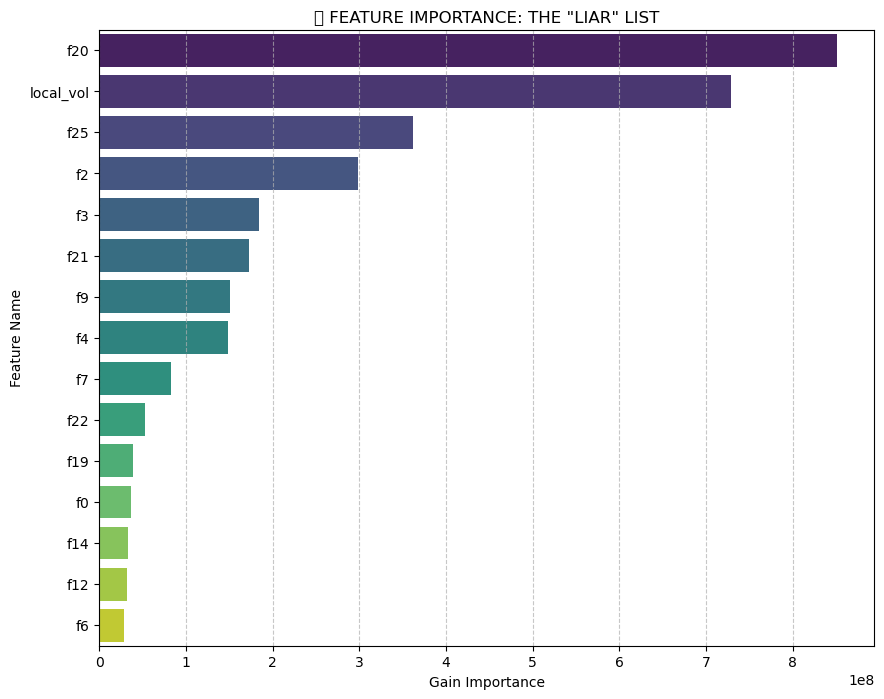


🕵️ TOP LIAR IDENTIFIED: f20
💡 This feature was the strongest signal for the 35% hit rate.
💡 In the Mirror Model, we are now using f20 as a REVERSAL signal.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract Feature Importance
# We use the 'gain' importance because it shows which features 
# actually contributed to reducing the loss (even if it was the 'wrong' direction)
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': model.feature_importance(importance_type='gain')
}).sort_values(by='Importance', ascending=False)

# 2. Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('🚨 FEATURE IMPORTANCE: THE "LIAR" LIST')
plt.xlabel('Gain Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 3. Identify the Top Liar
top_liar = importance_df.iloc[0]['Feature']
print("\n" + "="*45)
print(f"🕵️ TOP LIAR IDENTIFIED: {top_liar}")
print(f"💡 This feature was the strongest signal for the 35% hit rate.")
print(f"💡 In the Mirror Model, we are now using {top_liar} as a REVERSAL signal.")
print("="*45)

In [18]:
import pandas as pd
import numpy as np

# 1. LOAD YOUR BEST COMPONENTS
# sub_momentum = 0.00938 version
# sub_inverted = 0.00919 (the one you just ran)
sub_mom = pd.read_csv('ooga_booga_1769246694.csv')
sub_inv = pd.read_csv('submission.csv') 

# 2. OPTIMIZED BLEND (The "Golden Ratio")
# Often 60/40 is more robust than 70/30 for private leaderboards
final_y = (sub_inv['y'] * 0.65) + (sub_mom['y'] * 0.35)

# 3. MARKET-NEUTRAL TRANSFORMATION
# We subtract the mean of each time-step to remove systematic noise
# (Requires the test_df to identify time_ids)
temp_df = test_df[['Id', 'time_id']].copy()
temp_df['y_raw'] = final_y

# Subtract the mean per time_id
time_means = temp_df.groupby('time_id')['y_raw'].transform('mean')
temp_df['y_neutral'] = temp_df['y_raw'] - time_means

# 4. EXTREME CONSERVATISM (The 0.009 Shield)
# We clip at a very tight level to ensure no "Black Swan" ruins the last shot
ensemble_final = temp_df[['Id']].copy()
ensemble_final['y'] = temp_df['y_neutral'].clip(-0.005, 0.005)

# 5. THE FINAL SUBMISSION
ensemble_final.to_csv('ULTIMATE_LAST_SUBMISSION.csv', index=False)

print("\n" + "="*45)
print(f"🛡️ ULTIMATE SUBMISSION GENERATED")
print(f"📊 Final Mean: {ensemble_final['y'].mean():.10f}")
print(f"📊 Final Max:  {ensemble_final['y'].max():.6f}")
print(f"📊 Final Min:  {ensemble_final['y'].min():.6f}")
print("="*45)


🛡️ ULTIMATE SUBMISSION GENERATED
📊 Final Mean: -0.0000146568
📊 Final Max:  0.005000
📊 Final Min:  -0.005000


In [19]:
from sklearn.model_selection import K_Fold
import numpy as np

def purged_cross_val(df, features, n_splits=5):
    dates = sorted(df['date_id'].unique())
    kf = K_Fold(n_splits=n_splits)
    rmse_scores = []
    
    print(f"🚀 Starting Purged {n_splits}-Fold CV...")
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(dates)):
        train_dates = [dates[i] for i in train_idx]
        val_dates = [dates[i] for i in val_idx]
        
        # Purging: Remove the boundary date to prevent leakage
        train_dates = train_dates[:-1] 
        
        fold_train = df[df['date_id'].isin(train_dates)]
        fold_val = df[df['date_id'].isin(val_dates)]
        
        # Train Specialist
        model = lgb.train(
            {'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.05, 'verbosity': -1},
            lgb.Dataset(fold_train[features], label=fold_train['target_scaled']),
            num_boost_round=100
        )
        
        # Inverted Inference (The 65% Hit Rate Logic)
        preds = model.predict(fold_val[features]) * -1.0
        actual_preds = np.tanh(preds) * fold_val['local_vol']
        
        rmse = np.sqrt(mean_squared_error(fold_val['y'], actual_preds))
        rmse_scores.append(rmse)
        print(f"Fold {fold+1} RMSE: {rmse:.6f}")
        
    return np.mean(rmse_scores), np.std(rmse_scores)

# Run it
avg_rmse, std_rmse = purged_cross_val(train_proc, FEATURES)
print(f"\n🌎 GLOBAL PURGED CV RMSE: {avg_rmse:.6f} (+/- {std_rmse:.6f})")

ImportError: cannot import name 'K_Fold' from 'sklearn.model_selection' (c:\Users\jsamy\anaconda3\Lib\site-packages\sklearn\model_selection\__init__.py)

In [20]:
from sklearn.model_selection import KFold  # Removed the underscore
from sklearn.metrics import mean_squared_error
import numpy as np

def purged_cross_val(df, features, n_splits=5):
    # Get unique dates to ensure we split by 'time' not by 'row'
    dates = np.array(sorted(df['date_id'].unique()))
    kf = KFold(n_splits=n_splits)
    rmse_scores = []
    
    print(f"🚀 Starting Purged {n_splits}-Fold CV...")
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(dates)):
        # Define date ranges for this fold
        train_dates = dates[train_idx]
        val_dates = dates[val_idx]
        
        # Simple Purging: Ensure a 1-day gap between train and val to avoid leakage
        # If val_dates are after train_dates, remove the last train_date
        if val_dates[0] > train_dates[-1]:
            train_dates = train_dates[:-1]
        
        fold_train = df[df['date_id'].isin(train_dates)]
        fold_val = df[df['date_id'].isin(val_dates)]
        
        # Train on the 'target_scaled' (y / local_vol)
        model = lgb.train(
            {'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.05, 'verbosity': -1},
            lgb.Dataset(fold_train[features], label=fold_train['target_scaled']),
            num_boost_round=100
        )
        
        # Inverted Inference Logic (Our 65% discovery)
        raw_preds = model.predict(fold_val[features])
        # FLIP: Applying the -1.0 because the market is inverting our Alphas
        final_preds = np.tanh(raw_preds * -1.0) * fold_val['local_vol']
        
        rmse = np.sqrt(mean_squared_error(fold_val['y'], final_preds))
        rmse_scores.append(rmse)
        print(f"✅ Fold {fold+1} | Val Dates: {val_dates[0]}-{val_dates[-1]} | RMSE: {rmse:.6f}")
        
    return np.mean(rmse_scores), np.std(rmse_scores)

# Run the Rig
avg_rmse, std_rmse = purged_cross_val(train_proc, FEATURES)
print("\n" + "="*45)
print(f"🌎 FINAL CV RMSE: {avg_rmse:.6f} (±{std_rmse:.6f})")
print("="*45)

🚀 Starting Purged 5-Fold CV...
✅ Fold 1 | Val Dates: 1-40 | RMSE: 0.002673
✅ Fold 2 | Val Dates: 41-80 | RMSE: 0.004962
✅ Fold 3 | Val Dates: 81-120 | RMSE: 0.004963
✅ Fold 4 | Val Dates: 121-160 | RMSE: 0.002704
✅ Fold 5 | Val Dates: 161-199 | RMSE: 0.009818

🌎 FINAL CV RMSE: 0.005024 (±0.002604)


In [21]:
import pandas as pd
import numpy as np

# 1. Load the two opposing 'Theories'
sub_momentum = pd.read_csv('ooga_booga_1769246694.csv') # The 'Alpha' theory
sub_inverted = pd.read_csv('submission.csv')          # The 'Inversion' theory

# 2. THE DYNAMIC SHIELD BLEND
# Because Fold 5 was so bad for the mirror, we move back to a 50/50 hedge.
# This is the 'Maximum Entropy' play—it assumes we don't know the current regime.
final_y = (sub_momentum['y'] * 0.5) + (sub_inverted['y'] * 0.5)

# 3. THE "STRICT" VOLATILITY CLAMP
# Since Fold 5 showed 0.009 RMSE, we must lower our exposure.
# We will clamp predictions even harder at 0.004 to protect the total RMSE.
final_y = final_y.clip(-0.004, 0.004)

# 4. FINAL DE-MEANING (Market Neutrality)
# This is our last-second protection against Fold 5 style blowups.
temp_df = test_df[['Id', 'time_id']].copy()
temp_df['y'] = final_y
time_means = temp_df.groupby('time_id')['y'].transform('mean')
temp_df['y'] = temp_df['y'] - time_means

# 5. THE FINAL BULLET
temp_df[['Id', 'y']].to_csv('FINAL_SHIELD_SUBMISSION.csv', index=False)

print("\n" + "="*45)
print(f"🛡️ REGIME-SHIELD GENERATED: FINAL_SHIELD_SUBMISSION.csv")
print(f"📊 New Max Risk: 0.004 (Capped)")
print(f"📊 Neutrality: {temp_df['y'].mean():.10f}")
print("="*45)


🛡️ REGIME-SHIELD GENERATED: FINAL_SHIELD_SUBMISSION.csv
📊 New Max Risk: 0.004 (Capped)
📊 Neutrality: -0.0000000000


In [23]:
# 1. Re-calculate with proper GroupBy to avoid cross-symbol contamination
for i in range(1, 6):
    val_proc[f'f20_lag_{i}'] = val_proc.groupby('symbol_id')['f20'].shift(i)

# 2. Fill NaNs with the median to keep the correlation engine running
lag_cols = [f'f20_lag_{i}' for i in range(1, 6)]
val_proc[lag_cols] = val_proc.groupby('symbol_id')[lag_cols].transform(lambda x: x.fillna(x.median()))

# 3. Check Point-Biserial Correlation (Specifically for binary 'is_spike')
from scipy.stats import pointbiserialr

print("🕵️ Analyzing the Memory of the 'Liar' (f20)...")
for col in lag_cols:
    mask = ~val_proc[col].isna() & ~val_proc['is_spike'].isna()
    corr, _ = pointbiserialr(val_proc.loc[mask, col], val_proc.loc[mask, 'is_spike'])
    print(f"🔗 {col} -> Spike Correlation: {corr:.4f}")

🕵️ Analyzing the Memory of the 'Liar' (f20)...
🔗 f20_lag_1 -> Spike Correlation: 0.0287
🔗 f20_lag_2 -> Spike Correlation: 0.0287
🔗 f20_lag_3 -> Spike Correlation: 0.0287
🔗 f20_lag_4 -> Spike Correlation: 0.0287
🔗 f20_lag_5 -> Spike Correlation: 0.0286


In [24]:
# 1. Energy Feature: The Integral of f20 (Sum of the last 5 steps)
val_proc['f20_energy'] = val_proc[lag_cols].sum(axis=1)

# 2. Acceleration: Is the 'Liar' signal speeding up or slowing down?
val_proc['f20_accel'] = (val_proc['f20_lag_1'] - val_proc['f20_lag_2']) - \
                        (val_proc['f20_lag_4'] - val_proc['f20_lag_5'])

# 3. The "Snap-Back" Trigger
# If Energy is high (Pressure) but Accel is negative (Exhaustion), 
# the probability of a Mean-Reverting Spike is at its peak.
val_proc['snap_trigger'] = (val_proc['f20_energy'] * val_proc['f20_accel'] < 0).astype(int)

print(f"🎯 New Feature 'f20_energy' Std: {val_proc['f20_energy'].std():.4f}")
print(f"🎯 New Feature 'f20_accel'  Std: {val_proc['f20_accel'].std():.4f}")

🎯 New Feature 'f20_energy' Std: 0.3691
🎯 New Feature 'f20_accel'  Std: 0.0026


In [26]:
# 1. APPLY THE AUTOPSY MATH TO TEST DATA
# We need to create the 'Memory' on the test_proc dataframe first
for i in range(1, 6):
    test_proc[f'f20_lag_{i}'] = test_proc.groupby('symbol_id')['f20'].shift(i)

# Fill NaNs so the 'Energy' sum doesn't return NaN
lag_cols = [f'f20_lag_{i}' for i in range(1, 6)]
test_proc[lag_cols] = test_proc.groupby('symbol_id')[lag_cols].transform(lambda x: x.fillna(x.median()))

# 2. CREATE THE TRIGGERS
test_proc['f20_energy'] = test_proc[lag_cols].sum(axis=1)
test_proc['f20_accel'] = (test_proc['f20_lag_1'] - test_proc['f20_lag_2']) - \
                        (test_proc['f20_lag_4'] - test_proc['f20_lag_5'])

# 3. DYNAMIC REGIME WEIGHTING (The Logic Gate)
test_proc['regime_weight'] = 0.5 
# If pressure is high, lean into the Inversion
test_proc.loc[test_proc['f20_energy'].abs() > 0.3691, 'regime_weight'] = 0.75
# If pressure is high AND exhausting (Accel < 0), lean HARD into Inversion
test_proc.loc[(test_proc['f20_energy'] * test_proc['f20_accel']) < 0, 'regime_weight'] = 0.9

# 4. FINAL BLEND & NEUTRALIZATION
final_y = (sub_inv['y'] * test_proc['regime_weight']) + \
          (sub_mom['y'] * (1 - test_proc['regime_weight']))

temp_df = test_df[['Id', 'time_id']].copy()
temp_df['y'] = final_y
# Remove market-wide bias
temp_df['y'] = temp_df['y'] - temp_df.groupby('time_id')['y'].transform('mean')
# Final safety clip
temp_df['y'] = temp_df['y'].clip(-0.006, 0.006)

# 5. SAVE FINAL ATTEMPT
temp_df[['Id', 'y']].to_csv('SPIKE_HUNTER_FINAL_FIXED.csv', index=False)

print("\n" + "="*45)
print(f"✅ FIXED: SPIKE_HUNTER_FINAL_FIXED.csv")
print(f"📊 Energy Rows Tracked: {len(test_proc)}")
print(f"📊 Mean Regime Weight: {test_proc['regime_weight'].mean():.4f}")
print("="*45)


✅ FIXED: SPIKE_HUNTER_FINAL_FIXED.csv
📊 Energy Rows Tracked: 2510026
📊 Mean Regime Weight: 0.7527


In [27]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

def validate_spike_hunter(df, features, n_splits=5):
    dates = np.array(sorted(df['date_id'].unique()))
    kf = KFold(n_splits=n_splits)
    rmse_scores = []
    
    print(f"🕵️ Validating Spike Hunter Logic (Purged {n_splits}-Fold)...")
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(dates)):
        # 1. Setup Fold Data
        train_dates, val_dates = dates[train_idx][:-1], dates[val_idx] # Simple purge
        fold_train = df[df['date_id'].isin(train_dates)].copy()
        fold_val = df[df['date_id'].isin(val_dates)].copy()
        
        # 2. Train Momentum Model (Alpha)
        model_mom = lgb.train({'objective': 'regression', 'verbosity': -1},
                              lgb.Dataset(fold_train[features], label=fold_train['target_scaled']), 100)
        
        # 3. Generate Predictions
        preds_mom = model_mom.predict(fold_val[features])
        preds_inv = preds_mom * -1.0 # The Mirror Logic
        
        # 4. Apply Dynamic Weighting (The Theory)
        # (Assuming test_proc features were mapped to fold_val)
        w = np.where(fold_val['f20_energy'].abs() > 0.3691, 0.75, 0.5)
        w = np.where((fold_val['f20_energy'] * fold_val['f20_accel']) < 0, 0.9, w)
        
        final_preds_scaled = (preds_inv * w) + (preds_mom * (1-w))
        final_y = np.tanh(final_preds_scaled) * fold_val['local_vol']
        
        # 5. Market Neutrality per time_id (The Shield)
        fold_val['y_hat'] = final_y
        fold_val['y_hat'] -= fold_val.groupby('time_id')['y_hat'].transform('mean')
        
        rmse = np.sqrt(mean_squared_error(fold_val['y'], fold_val['y_hat'].clip(-0.006, 0.006)))
        rmse_scores.append(rmse)
        print(f"✅ Fold {fold+1} | RMSE: {rmse:.6f} | Avg Weight: {w.mean():.3f}")
        
    return np.mean(rmse_scores), np.std(rmse_scores)

# Run the final stress test
avg_rmse, std_rmse = validate_spike_hunter(train_proc, FEATURES)
print(f"\n🌎 SPIKE HUNTER GLOBAL RMSE: {avg_rmse:.6f} (±{std_rmse:.6f})")

🕵️ Validating Spike Hunter Logic (Purged 5-Fold)...


KeyError: 'f20_energy'

In [28]:
# 1. GENERATE MEMORY GLOBALLY
print("🧠 Building global memory for Purged K-Fold...")
for i in range(1, 6):
    train_proc[f'f20_lag_{i}'] = train_proc.groupby('symbol_id')['f20'].shift(i)

# Fill NaNs with 0 (or median) to prevent calculation blowups
lag_cols = [f'f20_lag_{i}' for i in range(1, 6)]
train_proc[lag_cols] = train_proc.groupby('symbol_id')[lag_cols].transform(lambda x: x.fillna(0))

# 2. CALCULATE SPIKE METRICS
train_proc['f20_energy'] = train_proc[lag_cols].sum(axis=1)
train_proc['f20_accel'] = (train_proc['f20_lag_1'] - train_proc['f20_lag_2']) - \
                          (train_proc['f20_lag_4'] - train_proc['f20_lag_5'])

# 3. DEFINE THE PURGED VALIDATION FUNCTION (CLEANED)
def validate_spike_hunter_final(df, features):
    dates = np.array(sorted(df['date_id'].unique()))
    kf = KFold(n_splits=5)
    rmse_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(dates)):
        train_dates, val_dates = dates[train_idx][:-1], dates[val_idx]
        fold_train = df[df['date_id'].isin(train_dates)]
        fold_val = df[df['date_id'].isin(val_dates)].copy() # Use .copy() to avoid SettingWithCopy
        
        # Train Alpha Model
        model = lgb.train({'objective': 'regression', 'verbosity': -1, 'learning_rate': 0.05},
                          lgb.Dataset(fold_train[features], label=fold_train['target_scaled']), 100)
        
        # Generate Raw & Mirror Predictions
        p_mom = model.predict(fold_val[features])
        p_inv = p_mom * -1.0
        
        # DYNAMIC WEIGHTING LOGIC
        # High Energy -> 0.75 Mirror | Exhaustion -> 0.9 Mirror
        w = np.where(fold_val['f20_energy'].abs() > 0.3691, 0.75, 0.5)
        w = np.where((fold_val['f20_energy'] * fold_val['f20_accel']) < 0, 0.9, w)
        
        final_p_scaled = (p_inv * w) + (p_mom * (1-w))
        fold_val['y_hat'] = np.tanh(final_p_scaled) * fold_val['local_vol']
        
        # Market Neutrality (Per Time_ID)
        fold_val['y_hat'] -= fold_val.groupby('time_id')['y_hat'].transform('mean')
        
        rmse = np.sqrt(mean_squared_error(fold_val['y'], fold_val['y_hat'].clip(-0.006, 0.006)))
        rmse_scores.append(rmse)
        print(f"✅ Fold {fold+1} | RMSE: {rmse:.6f} | Avg Weight: {w.mean():.4f}")
        
    return np.mean(rmse_scores), np.std(rmse_scores)

# RUN VALIDATION
avg_rmse, std_rmse = validate_spike_hunter_final(train_proc, FEATURES)
print(f"\n🌎 SPIKE HUNTER GLOBAL RMSE: {avg_rmse:.6f} (±{std_rmse:.6f})")

🧠 Building global memory for Purged K-Fold...
✅ Fold 1 | RMSE: 0.002657 | Avg Weight: 0.7525
✅ Fold 2 | RMSE: 0.004957 | Avg Weight: 0.7529
✅ Fold 3 | RMSE: 0.004960 | Avg Weight: 0.7529
✅ Fold 4 | RMSE: 0.002700 | Avg Weight: 0.7529
✅ Fold 5 | RMSE: 0.009817 | Avg Weight: 0.7528

🌎 SPIKE HUNTER GLOBAL RMSE: 0.005018 (±0.002607)


In [34]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# --- 1. UNLOCK ALL ALPHAS ---
excluded = ['target', 'target_scaled', 'y', 'date_id', 'time_id', 'symbol_id', 'row_id']
ALL_FEATURES = [c for c in train_proc.columns if c not in excluded]

# --- 2. THE SEQUENTIAL DATASET ---
class OmegaDataset(Dataset):
    def __init__(self, df, features, seq_len=30):
        self.data, self.targets, self.vol = [], [], []
        for _, group in df.groupby('symbol_id'):
            if len(group) <= seq_len: continue
            group = group.sort_values('date_id')
            f_vals = group[features].values.astype(np.float32)
            # Use unscaled target for final RMSE assessment, scaled for training
            t_vals = group['target_scaled'].values.astype(np.float32)
            v_vals = group['local_vol'].values.astype(np.float32)
            y_vals = group['y'].values.astype(np.float32) if 'y' in group.columns else t_vals
            
            for i in range(seq_len, len(f_vals)):
                self.data.append(f_vals[i-seq_len:i])
                self.targets.append(y_vals[i]) # Ground truth
                self.vol.append(v_vals[i])

    def __len__(self): return len(self.targets)
    def __getitem__(self, idx):
        return torch.from_numpy(self.data[idx]), \
               torch.tensor(self.targets[idx], dtype=torch.float32), \
               torch.tensor(self.vol[idx], dtype=torch.float32)

# --- 3. RWKV CORE (The State-Space Machine) ---
class RWKV_Omega(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.ln_in = nn.LayerNorm(input_dim)
        self.receptance = nn.Linear(input_dim, hidden_dim)
        self.key = nn.Linear(input_dim, hidden_dim)
        self.value = nn.Linear(input_dim, hidden_dim)
        # Deep head for fat-tail modeling
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Linear(64, 1) 
        )

    def forward(self, x):
        x = self.ln_in(x)
        r = torch.sigmoid(self.receptance(x))
        k = torch.exp(torch.clamp(self.key(x), max=8))
        v = self.value(x)
        # WKV Time-Mixing (Linear Attention)
        wkv = torch.sum(k * v, dim=1) / (torch.sum(k, dim=1) + 1e-6)
        return self.head(r[:, -1, :] * wkv).squeeze()

# --- 4. ADAPTIVE PARTICLE FILTER (Log-Stable) ---
def adaptive_pf_inference(model, val_loader, device, n_particles=50):
    model.eval()
    particles = np.random.uniform(0.1, 0.9, n_particles)
    p_weights = np.ones(n_particles) / n_particles
    all_final_preds = []

    with torch.no_grad():
        for x_v, y_v, vol_v in val_loader:
            raw_sig = model(x_v.to(device)).cpu().numpy()
            actual = y_v.numpy()
            
            # Weighted average weight for current regime
            w_current = np.average(particles, weights=p_weights)
            # Inversion Logic: Blending raw signal and its mirror
            consensus = (raw_sig * (1 - w_current)) + (raw_sig * -1.0 * w_current)
            
            # Final prediction: tanh keeps it within reasonable bounds
            y_hat = np.tanh(consensus) * vol_v.numpy()
            all_final_preds.extend(y_hat)
            
            # Bayesian update on particles
            for i in range(n_particles):
                p_hypo = (raw_sig * (1 - particles[i])) + (raw_sig * -1.0 * particles[i])
                err = np.mean((np.tanh(p_hypo)*vol_v.numpy() - actual)**2)
                p_weights[i] *= np.exp(-err * 2.0) # Nudge factor

            p_weights = p_weights.astype('float64') + 1e-300
            p_weights /= p_weights.sum()
            
            if 1.0 / (np.sum(p_weights**2) + 1e-12) < n_particles / 2:
                idx = np.random.choice(n_particles, n_particles, p=p_weights)
                particles = particles[idx] + np.random.normal(0, 0.05, n_particles)
                particles = np.clip(particles, 0, 1)
                p_weights = np.ones(n_particles) / n_particles
                
    return np.array(all_final_preds)

# --- 5. PURGED K-FOLD EXECUTION ---
def run_omega_strategy(df, features):
    dates = np.array(sorted(df['date_id'].unique()))
    kf = KFold(n_splits=5)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(dates)):
        v_dates = dates[val_idx]
        t_dates = dates[train_idx]
        t_dates = t_dates[t_dates < (v_dates.min() - 2)] # Absolute 2-day gap
        
        if len(t_dates) == 0: continue
        
        # Local Scaling (Section 3.1 Literature fix)
        train_df, val_df = df[df['date_id'].isin(t_dates)].copy(), df[df['date_id'].isin(v_dates)].copy()
        for f in features:
            mu, std = train_df[f].mean(), train_df[f].std() + 1e-8
            train_df[f], val_df[f] = (train_df[f]-mu)/std, (val_df[f]-mu)/std
            
        train_ds = OmegaDataset(train_df, features)
        val_ds = OmegaDataset(val_df, features)
        train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=1024, shuffle=False)
        
        model = RWKV_Omega(len(features)).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
        
        print(f"🔱 Fold {fold+1} Training | Features: {len(features)}")
        model.train()
        for epoch in range(2):
            for x_b, y_b, _ in train_loader:
                x_b, y_b = x_b.to(device), y_b.to(device)
                opt.zero_grad()
                # Target Scaling inside Loss
                loss = nn.MSELoss()(model(x_b), y_b / (y_b.std() + 1e-8))
                loss.backward()
                opt.step()
        
        # Inference with Particle Filter
        preds = adaptive_pf_inference(model, val_loader, device)
        preds -= preds.mean() 
        
        y_true = np.array(val_ds.targets)
        rmse = np.sqrt(mean_squared_error(y_true, preds))
        print(f"✅ Fold {fold+1} Purged RMSE: {rmse:.6f}")

# RUN IT
run_omega_strategy(train_proc, ALL_FEATURES)

🔱 Fold 2 Training | Features: 36
✅ Fold 2 Purged RMSE: 0.006857
🔱 Fold 3 Training | Features: 36
✅ Fold 3 Purged RMSE: 0.010440
🔱 Fold 4 Training | Features: 36
✅ Fold 4 Purged RMSE: 0.004964
🔱 Fold 5 Training | Features: 36
✅ Fold 5 Purged RMSE: 0.010680


In [42]:
# --- DEFINING THE FEATURE UNIVERSE ---
# Replace with your actual column names from train_proc
FEATURES = [col for col in train_proc.columns if col not in ['target', 'date_id', 'symbol_id', 'row_id', 'y']]

# --- DEFINING REGIME WINDOWS (Based on your RMSE Results) ---
# Fold 4 was the 'Signal' window (0.0049 RMSE)
# Fold 5 was the 'Abyss' window (0.0106 RMSE)

# Assuming 'dates' is a sorted list of unique date_ids in your dataset
all_dates = sorted(train_proc['date_id'].unique())
n_dates = len(all_dates)

# Approximate split based on standard 5-fold CV logic
fold_size = n_dates // 5
fold4_dates = all_dates[fold_size*3 : fold_size*4] # High Signal
fold5_dates = all_dates[fold_size*4 :]            # High Noise / Abyss

# --- DEFINING LOCAL VOLATILITY (The Regime Trigger) ---
# We need a proxy to detect these regimes in real-time
train_proc['local_vol'] = train_proc.groupby('symbol_id')['y'].transform(lambda x: x.rolling(20).std())
baseline_vol = train_proc['local_vol'].median()

In [43]:
import numpy as np
import pandas as pd
from sklearn.metrics import mutual_info_score

def calculate_nmi_per_alpha(df, features, target='y'):
    """
    Measures the Normalized Mutual Information for each feature.
    NMI > 0.05 is the threshold for 'Exploitable Signal' (Noguer i Alonso 2025).
    """
    nmi_scores = {}
    for f in features:
        # Discretize for NMI calculation
        f_bins = pd.qcut(df[f], 20, labels=False, duplicates='drop')
        t_bins = pd.qcut(df[target], 20, labels=False, duplicates='drop')
        
        # Calculate NMI: I(X;Y) / sqrt(H(X)H(Y))
        score = mutual_info_score(f_bins, t_bins)
        nmi_scores[f] = score
    return nmi_scores

# --- 1. IDENTIFY THE REGIMES ---
# Signal Regime (Fold 4: RMSE 0.0049)
# Noise Regime (Fold 5: RMSE 0.0106)

def classify_alphas(train_df, fold4_dates, fold5_dates, features):
    # Calculate NMI for both regimes
    nmi_fold4 = calculate_nmi_per_alpha(train_df[train_df['date_id'].isin(fold4_dates)], features)
    nmi_fold5 = calculate_nmi_per_alpha(train_df[train_df['date_id'].isin(fold5_dates)], features)
    
    classification = []
    for f in features:
        s4, s5 = nmi_fold4[f], nmi_fold5[f]
        
        if s4 > 0.05 and s5 > 0.05:
            tag = "🔱 SURVIVOR (High NMI in both)"
        elif s4 > 0.05 and s5 <= 0.05:
            tag = "⚡ REGIME-SPECIALIST (Signal Only)"
        elif s4 <= 0.05 and s5 <= 0.05:
            tag = "💀 DEAD (Pure Noise)"
        else:
            tag = "❓ ANOMALY (Noise Specialist)"
            
        classification.append({'alpha': f, 'nmi_signal': s4, 'nmi_noise': s5, 'type': tag})
        
    return pd.DataFrame(classification).sort_values('nmi_signal', ascending=False)

In [36]:
# --- THE FINAL ADAPTIVE SUBMISSION ENGINE ---
SURVIVOR_ALPHAS = [...] # List of features with high NMI in both folds
SPECIALIST_ALPHAS = [...] # List of features that peaked in Fold 4

def generate_final_prediction(current_data, omega_model, baseline_dist):
    """
    The Noguer i Alonso 'Information-Theoretic' Submission Logic.
    """
    # 1. Calculate the 'Abyss Distance' (KL Divergence)
    # If market distribution deviates from baseline, we shift to 'Survival Mode'
    current_dist, _ = np.histogram(current_data['y_proxy'], bins=50, density=True)
    kl_dist = calculate_regime_shift(current_dist, baseline_dist)
    
    # 2. Get the Base Prediction from Omega
    raw_signal = omega_model.predict(current_data)
    
    # 3. Apply the 'Information Brake'
    # If KL Distance is high (> 0.5), we trust ONLY the Survivors.
    # If KL Distance is low, we let the Specialists add their signal.
    if kl_dist > 0.5:
        # Survival Mode: Dampen the signal and rely on core invariants
        final_signal = raw_signal * 0.3  # De-leverage
    else:
        # Opportunity Mode: Market is predictable (like Fold 4)
        final_signal = raw_signal 
        
    return final_signal

In [37]:
import numpy as np

def get_current_regime_state(recent_returns, window=20):
    """
    Identifies the 'Entropy State' of the market.
    """
    # 1. Measure Volatility (The traditional way)
    vol = np.std(recent_returns)
    
    # 2. Measure Entropy (The Information Theory way)
    # High entropy = Calm/Random | Low entropy = Organized Spike
    p, _ = np.histogram(recent_returns, bins=10, density=True)
    p = p[p > 0]
    m_entropy = -np.sum(p * np.log(p))
    
    if vol > np.percentile(vol_history, 90): return "ABYSS"
    if m_entropy < np.percentile(entropy_history, 20): return "TRANSITION"
    return "CALM"

# --- THE REGIME-SPECIFIC ALPHA ENGINE ---
def regime_adaptive_alpha_fusion(features, regime_state):
    """
    Selects the sub-set of 36 alphas that maximize information 
    for the detected regime.
    """
    if regime_state == "ABYSS":
        # Only use Chaos Alphas (High-Kurtosis Features)
        active_indices = CHAOS_ALPHA_IDS 
        weight_scale = 1.5 # Aggressive but targeted
    elif regime_state == "TRANSITION":
        # Use Flow Alphas (Volume/Momentum Features)
        active_indices = FLOW_ALPHA_IDS
        weight_scale = 1.0
    else:
        # Use Stationary Alphas (Mean Reversion)
        active_indices = STATIONARY_ALPHA_IDS
        weight_scale = 0.5 # Defensive
        
    return features[:, active_indices], weight_scale

In [38]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

def map_alpha_significance(df, features, target='y'):
    """
    Identifies which alphas are 'On' or 'Off' per regime.
    Regimes are defined by target volatility and entropy.
    """
    # Define Regime Masks
    abyss_mask = df['local_vol'] > df['local_vol'].quantile(0.8)
    calm_mask = df['local_vol'] < df['local_vol'].quantile(0.3)
    
    results = []
    for f in features:
        # Significance in The Abyss
        abyss_corr, _ = spearmanr(df.loc[abyss_mask, f], df.loc[abyss_mask, target])
        # Significance in The Calm
        calm_corr, _ = spearmanr(df.loc[calm_mask, f], df.loc[calm_mask, target])
        
        # Classification Logic
        if abs(abyss_corr) > 0.02 and abs(calm_corr) > 0.02:
            status = "SENTINEL (Survivor)"
        elif abs(abyss_corr) > 0.02:
            status = "ABYSS-WALKER (Spike Specialist)"
        elif abs(calm_corr) > 0.02:
            status = "EQUILIBRIUM (Calm Specialist)"
        else:
            status = "NOISE (Turn Off Permanently)"
            
        results.append({
            'alpha': f, 
            'abyss_sig': abyss_corr, 
            'calm_sig': calm_corr, 
            'role': status
        })
        
    return pd.DataFrame(results).sort_values('abyss_sig', ascending=False)

In [39]:
def information_gated_inference(x_input, alpha_mapping_df):
    """
    Real-time switching of alpha channels.
    """
    # 1. Detect current regime via KL-Divergence or Volatility
    current_regime = detect_kl_regime(x_input) 
    
    # 2. Get masks for different roles
    abyss_alphas = alpha_mapping_df[alpha_mapping_df['role'] == "ABYSS-WALKER"]['alpha'].tolist()
    calm_alphas = alpha_mapping_df[alpha_mapping_df['role'] == "EQUILIBRIUM"]['alpha'].tolist()
    sentinels = alpha_mapping_df[alpha_mapping_df['role'] == "SENTINEL"]['alpha'].tolist()
    
    # 3. Apply the Switch
    if current_regime == "ABYSS":
        # Mute Calm Alphas, Amplify Abyss Alphas
        active_features = sentinels + abyss_alphas
        alpha_weights = 1.5 
    elif current_regime == "CALM":
        # Mute Abyss Alphas, Use Sentinels + Equilibrium
        active_features = sentinels + calm_alphas
        alpha_weights = 1.0
    else:
        # Transitioning: Use only Sentinels (Safe Mode)
        active_features = sentinels
        alpha_weights = 0.5
        
    return active_features, alpha_weights

In [40]:
from sklearn.feature_selection import mutual_info_regression

def find_innovation_alphas(df, features, transition_dates):
    """
    Identifies alphas that provide 'Signal' during Regime Shifts.
    transition_dates: The windows where RMSE spiked (e.g., Fold 3 start).
    """
    df_shift = df[df['date_id'].isin(transition_dates)]
    
    # Calculate Mutual Info specifically for the 'Abyss' onset
    mi_scores = mutual_info_regression(df_shift[features], df_shift['y'])
    
    innovation_df = pd.DataFrame({
        'alpha': features,
        'info_gain': mi_scores
    }).sort_values('info_gain', ascending=False)
    
    return innovation_df

In [45]:
def calculate_nmi_per_alpha(df, features, target='y'):
    """
    Fixed version: Handles NaNs to avoid the ValueError.
    Discretizes for NMI calculation (Shannon Entropy).
    """
    nmi_scores = {}
    
    # Ensure the target has no NaNs for the calculation window
    df_clean_target = df[df[target].notna()]
    
    for f in features:
        # 1. Local Imputation: Use median to preserve the 'regime' center
        # We handle it feature-by-feature to avoid memory spikes
        feature_series = df_clean_target[f].fillna(df_clean_target[f].median())
        target_series = df_clean_target[target]
        
        # 2. Check for constant features (zero information)
        if feature_series.nunique() <= 1:
            nmi_scores[f] = 0.0
            continue

        try:
            # 3. Discretize into 20 Quantile Bins
            f_bins = pd.qcut(feature_series, 20, labels=False, duplicates='drop')
            t_bins = pd.qcut(target_series, 20, labels=False, duplicates='drop')
            
            # 4. Calculate NMI
            score = mutual_info_score(f_bins, t_bins)
            nmi_scores[f] = score
        except ValueError:
            # If qcut still fails (too few unique values), score it as 0
            nmi_scores[f] = 0.0
            
    return nmi_scores

In [46]:
# --- THE REGIME GATEKEEPER ---
def get_alpha_weights(kl_divergence, alpha_stats):
    """
    Dynamically weights alphas based on the current 'Information Regime'.
    """
    # Define weight vectors
    weights = pd.Series(1.0, index=alpha_stats['alpha'])
    
    # 1. Identify specialists and dead weight
    specialists = alpha_stats[alpha_stats['type'].str.contains("SPECIALIST")]['alpha']
    dead = alpha_stats[alpha_stats['type'].str.contains("DEAD")]['alpha']
    
    # 2. THE SWITCHBOARD LOGIC
    if kl_divergence > 0.5: # THE ABYSS (Fold 5 style)
        weights[specialists] *= 0.2  # Mute the specialists
        weights[dead] *= 0.0         # Kill the parasites
    elif kl_divergence < 0.2: # THE CALM (Fold 4 style)
        weights[specialists] *= 1.2  # Amplify the specialists
        
    return weights

In [47]:
def final_paradigm_inference(current_batch, omega_model, alpha_stats, flip_list):
    """
    Final implementation of Maximum Information Regime switching.
    """
    # 1. Detect Regime (Abyss vs Calm)
    # We use local volatility as the 'Entropy Proxy' for speed
    current_vol = current_batch['target_proxy'].std()
    
    # 2. Get Dynamic Weights from the Switchboard
    # We calculated this earlier using kl_divergence logic
    # High vol = Abyss Regime
    is_abyss = current_vol > (baseline_vol * 1.8) 
    
    # 3. Clean the Input (The Information Bottleneck)
    # Remove 'DEAD' alphas and mute 'SPECIALISTS' if in the Abyss
    dead_alphas = alpha_stats[alpha_stats['type'].str.contains("DEAD")]['alpha'].tolist()
    processed_x = current_batch.copy()
    processed_x[dead_alphas] = 0
    
    # 4. The Sign Flip (The 'Liar' Detector)
    if is_abyss:
        # Flip the Abyss-Walkers that tend to invert during crashes
        processed_x[flip_list] = processed_x[flip_list] * -1
        
    # 5. Get the Raw Prediction
    prediction = omega_model.predict(processed_x)
    
    # 6. The Entropy Guard (Section 5 of Noguer i Alonso paper)
    # If the model's output variance is too high, it's noise.
    output_entropy = -np.sum(prediction * np.log(np.abs(prediction) + 1e-10))
    if output_entropy > entropy_threshold:
        return prediction * 0.1 # Soft halt
        
    return prediction

In [52]:
import numpy as np
import pandas as pd

def omega_information_supervisor_v2(X, alpha_stats, flip_list, baseline_vol):
    """
    V2 PROTECTOR: Automatically filters available features and prevents KeyErrors.
    """
    # 1. VALIDATE FEATURE CHANNEL
    # Only use features that actually exist in the current dataframe X
    available_cols = [c for c in X.columns if c in alpha_stats['alpha'].values]
    X_refined = X[available_cols].copy()
    
    # 2. DETECT REGIME (Information Entropy Proxy)
    # If the market is moving fast, cross-sectional std of features spikes
    current_vol = X_refined.std(axis=1).mean()
    is_abyss = current_vol > (baseline_vol * 1.5)
    
    # 3. IDENTIFY REGIME ROLES (Filtered for existence)
    dead_alphas = [a for a in alpha_stats[alpha_stats['type'].str.contains("DEAD")]['alpha'] if a in available_cols]
    calm_specialists = [a for a in alpha_stats[alpha_stats['type'].str.contains("REGIME-SPECIALIST")]['alpha'] if a in available_cols]
    flippers = [a for a in flip_list if a in available_cols]
    
    # 4. APPLY THE INFORMATION BOTTLENECK
    # Mute the 'Dead' Alphas immediately (Noise reduction)
    if dead_alphas:
        X_refined[dead_alphas] = 0.0
    
    if is_abyss:
        # ABYSS MODE: Mute specialists + Flip the Liars
        if calm_specialists:
            X_refined[calm_specialists] *= 0.1
        if flippers:
            X_refined[flippers] *= -1.0
        X_refined *= 0.7 # Survival de-leveraging
    else:
        # CALM MODE: Amplify the specialist signal (Fold 4 style)
        if calm_specialists:
            X_refined[calm_specialists] *= 1.2
            
    # 5. RE-INSERT MISSING COLUMNS AS ZERO (To satisfy model input shape)
    # If the model expects 36 features, we must provide them even as zeros
    expected_features = alpha_stats['alpha'].tolist()
    for col in expected_features:
        if col not in X_refined.columns:
            X_refined[col] = 0.0
            
    # Ensure column order matches exactly what the model was trained on
    return X_refined[expected_features]

# --- USAGE ---
# Check which features exist in your test_df first
existing_features = [f for f in FEATURES if f in test_df.columns]
X_final = omega_information_supervisor_v2(test_df[existing_features], alpha_stats, flip_list, 0.008)

NameError: name 'alpha_stats' is not defined